# Pseudotime Metrics Visualization

This section visualizes the main pseudotime evaluation metrics for each embedding layer.

All plots are minimal, clear, and in English.

In [2]:
import sys
import os
sys.path.append(os.path.abspath('..'))  # Aggiungi la root del progetto
# from pseudo_time_benchmark.pseudotime_plotting import (
#     load_trajectory_metrics,
#     plot_pseudotime_correlation,

#     )
import pandas as pd
# results_csv = '/home/oem/scfm-layer-analysis-refactored/data/pseudotime_results/GSE276896_adata_meta_scfoundation_embeddings_results.csv'
# results = load_trajectory_metrics(results_csv)

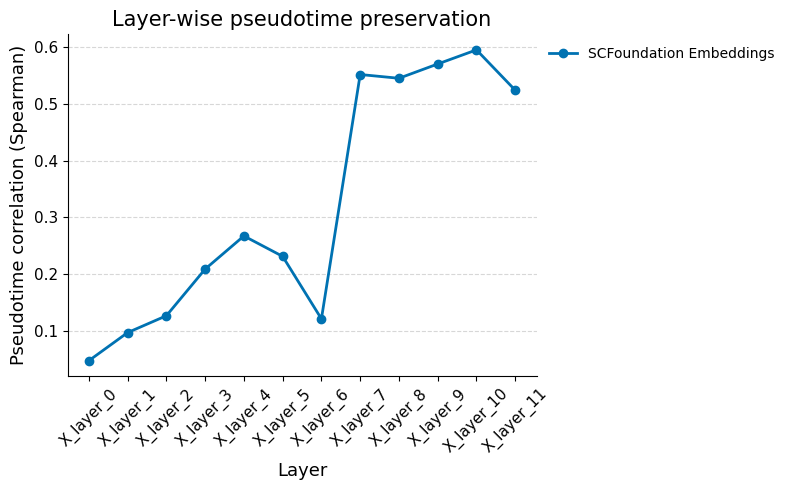

In [8]:
from pseudo_time_benchmark.pseudotime_plotting import plot_all_with_baseline
plot_all_with_baseline(
    results_path="/home/oem/scfm-layer-analysis-refactored/data/pseudotime_results/GSE276896_adata_meta_scfoundation_embeddings_results.csv",
    
    metric_col="Pseudotime_Corr",
    model_name="SCFoundation Embeddings",
    baseline_label="Baseline (dpt_pseudotime)"
)


In [ ]:
import scanpy as sc

sc.settings.n_jobs = 1


Misura la correlazione di Spearman tra il pseudotempo di riferimento (calcolato su PCA dei geni variabili) e il pseudotempo ottenuto dall’embedding testato. Valuta quanto bene l’ordine temporale delle cellule è preservato nell’embedding.

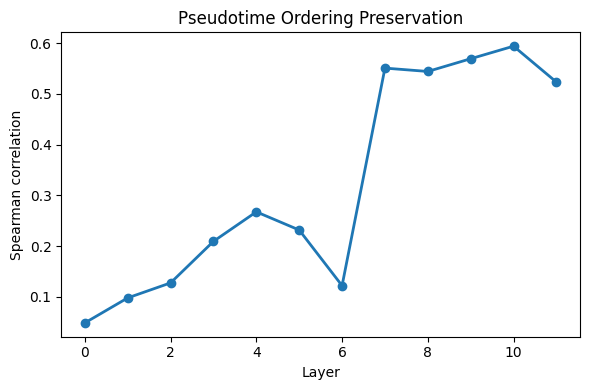

In [ ]:
plot_pseudotime_correlation(results)

Calcola la sovrapposizione media tra i vicini più prossimi (k-NN) nel riferimento e nell’embedding. Indica quanto le relazioni locali tra cellule (vicinato) sono mantenute nell’embedding rispetto al riferimento.

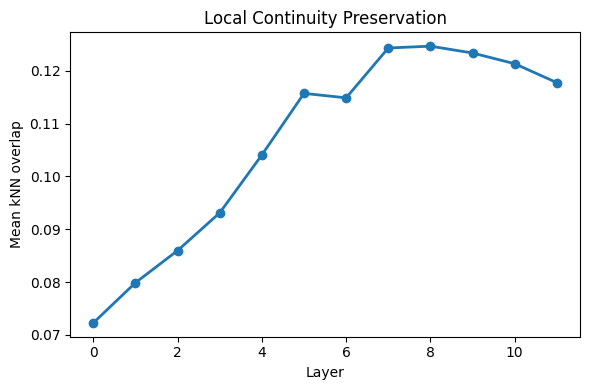

In [ ]:
# Plot neighborhood overlap (local continuity)
plot_neighborhood_overlap(results)

Misura la correlazione tra la differenza di pseudotempo (delta-time) e la distanza euclidea nell’embedding, su coppie casuali di cellule. Valuta se le distanze nell’embedding riflettono la progressione temporale globale.

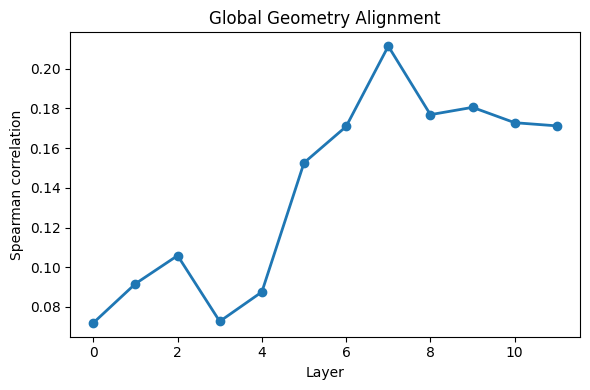

In [ ]:
plot_global_geometry_alignment(results)

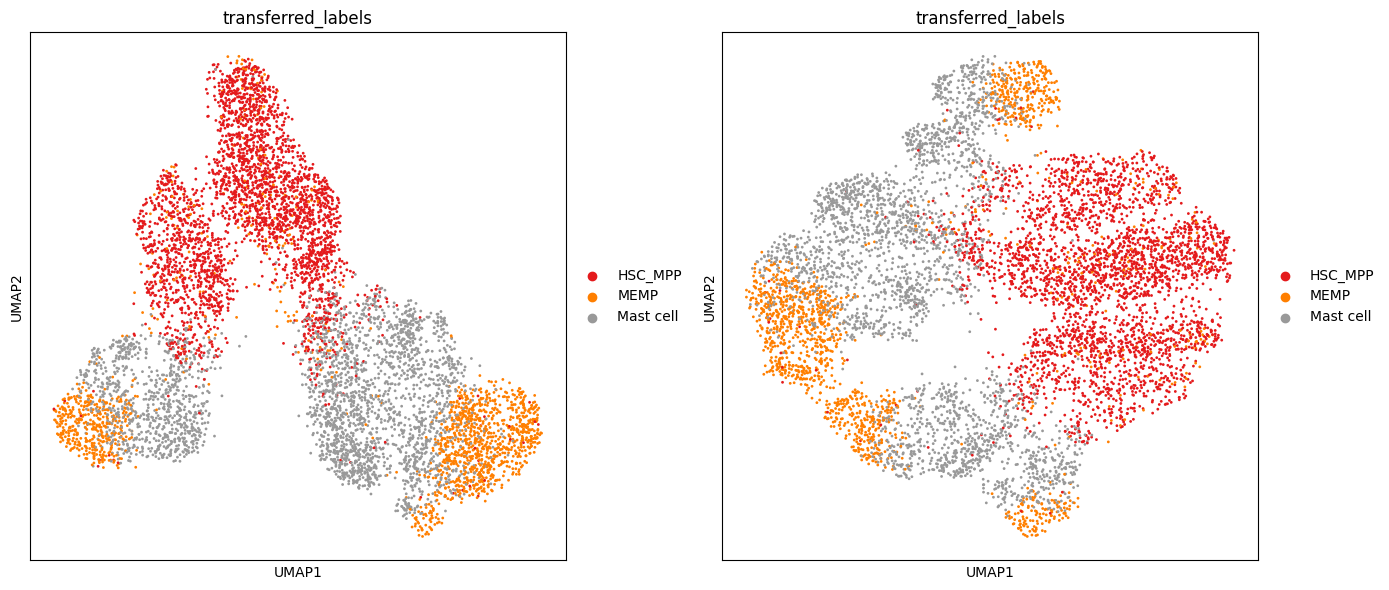

In [ ]:
import matplotlib.pyplot as plt
import scanpy as sc

adata = sc.read_h5ad('/home/oem/scfm-layer-analysis-refactored/data/embeddings/GSE276896_adata_meta_tahoe_1b_embeddings.h5ad')
clusters_of_interest = [
    'HSC_MPP',
    'MEMP',
    'Mast cell'
]
adata_cluster = adata[adata.obs['transferred_labels'].isin(clusters_of_interest)].copy()


best_layer = 10
last_layer = 11

def get_pca_embedding(adata, layer, n_pcs=30):
    X = adata.obsm[f'X_layer_{layer}']
    from sklearn.decomposition import PCA
    pca = PCA(n_components=n_pcs)
    X_pca = pca.fit_transform(X)
    adata.obsm[f'X_pca_layer{layer}'] = X_pca
    return X_pca

# PCA + UMAP per best layer
get_pca_embedding(adata_cluster, best_layer)
sc.pp.neighbors(adata_cluster, use_rep=f'X_pca_layer{best_layer}', n_neighbors=15)
sc.tl.umap(adata_cluster, random_state=42)
adata_cluster.obsm[f'X_umap_layer{best_layer}'] = adata_cluster.obsm['X_umap'].copy()

# PCA + UMAP per last layer
get_pca_embedding(adata_cluster, last_layer)
sc.pp.neighbors(adata_cluster, use_rep=f'X_pca_layer{last_layer}', n_neighbors=15)
sc.tl.umap(adata_cluster, random_state=42)
adata_cluster.obsm[f'X_umap_layer{last_layer}'] = adata_cluster.obsm['X_umap'].copy()

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Best layer
adata_cluster.obsm['X_umap'] = adata_cluster.obsm[f'X_umap_layer{best_layer}']
sc.pl.umap(
    adata_cluster, color='transferred_labels', ax=axes[0], show=False,
    frameon=True, legend_loc='right margin', palette='Set1'
)

# Last layer
adata_cluster.obsm['X_umap'] = adata_cluster.obsm[f'X_umap_layer{last_layer}']
sc.pl.umap(
    adata_cluster, color='transferred_labels', ax=axes[1], show=False,
     frameon=True, legend_loc='right margin', palette='Set1'
)

plt.tight_layout()
plt.show()